# Fit of the LECs for the NNLO project (this is the fit with the infinite volume limit)

# Parameters $l_1^r$,...,$l_5^r$ and $r_{F,2}^r$.

In [ ]:
#import the necessary libraries

import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

## Define the beta and the number of points $r_i$ we take

In [3]:
#HOW MANY r - POINTS ARE WE USING?

#WHAT IS THE BETA? CHOOSE IT
#n_beta = 1 for 6.9
#n_beta = 2 for 7.05
#n_beta = 3 for 7.2

n_beta = 3

#n_r_point = 4; # 5 for 6.9 and 7.2; 4 for 7.05

if n_beta == 1:
    n_r_point = 5
if n_beta == 2:
    n_r_point = 4
if n_beta == 3:
    n_r_point = 5

## Read the data. We use the same data as for the NLO project.

In [6]:
#file_path_Kulkarni = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/latticeresultsKulkarniFull_InfiniteVolume.csv'
data_Kulkarni =  np.loadtxt('Data/latticeresultsKulkarniFull_InfiniteVolume.csv', delimiter = ';', skiprows = 1) # Use skip_header=1 if you want to skip the header row

table6 = data_Kulkarni[:32]        
table7 = data_Kulkarni[32:63] #we are interested in this table mostly    
table8 = data_Kulkarni[63:]  

In [8]:
#function which extracts data for different betas 
def extract_rows_by_value(matrix):
    """
    The function takes a 2D NumPy array and extracts the rows where the first column contains the values 6.9, 7.05, or 7.2.
    """
    values_to_extract = {6.9, 7.05, 7.2}  # Устанавливаем нужные значения

    # Извлекаем строки, соответствующие указанным значениям
    extracted_6_9 = matrix[np.isclose(matrix[:, 0], 6.9)]
    extracted_7_05 = matrix[np.isclose(matrix[:, 0], 7.05)]
    extracted_7_2 = matrix[np.isclose(matrix[:, 0], 7.2)]    

    return extracted_6_9, extracted_7_05, extracted_7_2

#function which extracts the data from the matrices 
def process_matrices_for_different_betas(matrices):
   
    results = []
    
    for matrix in matrices:
        mPiA = matrix[:, 3]  # mass of type A
        DmPiA = matrix[:, 4]  # error of mass of type A
        mPiASquared = mPiA * mPiA  # Squared mass of type A
        DmPiASquared = 2 * mPiA * DmPiA  # error of squared mass of type A

        mPiC = matrix[:, 5]  # mass of type C
        DmPiC = matrix[:, 6]  # error of mass of type C
        mPiCSquared = mPiC * mPiC  # Squared mass of type C
        DmPiCSquared = 2 * mPiC * DmPiC  # error of squared mass of type C

        fA = matrix[:, 7]  # decay constant of type A
        DfA = matrix[:, 8]  # error of decay constant of type A

        fC = matrix[:, 9]  # decay constant of type C
        DfC = matrix[:, 10]  # error of decay constant of type C

        #Averaging
        fAverage = (fA+fC)/2
        
        DfAverage = (DfA+DfC)/2 #statistical error
        systematic_F_error = np.abs(fA - fC)/2 #systematic error

        Fsigma_eff = np.sqrt(DfAverage**2 + systematic_F_error**2)

    
    
        # Compute x2A and x2C
        x2A = mPiASquared / (fA ** 2)
        Dx2A = 2 * (mPiASquared * fA * DfA + fA ** 2 * mPiA * DmPiA) / fA ** 4

        x2C = mPiCSquared / (fA ** 2)
        Dx2C = 2 * (mPiCSquared * fA * DfA + fA ** 2 * mPiC * DmPiA) / fA ** 4

        # Another option taking fC into account
        x2C_new = mPiCSquared / (fC ** 2)
        Dx2C_new = 2 * (mPiCSquared * fC * DfC + fC ** 2 * mPiC * DmPiC) / fC ** 4

        # X-axis
        mAverage = matrix[:, 11]  # average PCAC mass
        DmAverage = matrix[:, 12]  # error of average PCAC mass

        mu = mAverage[-1]  # mu stays fixed
        Dmu = DmAverage[-1]  # error of mu

        r = -1 + 2 * mAverage / mu  # ratio r=md/mu
        Dr = 2 / (mu ** 2) * (mAverage * Dmu + mu * DmAverage)  # error of r=mu/md

        #bared quark masses
        mu0 = matrix[:, 1]
        md0 = matrix[:, 2]

         # Store results as dictionary
        results.append({
            "mu0": mu0,
            "md0": md0,
            "mPiASquared": mPiASquared,
            "DmPiASquared": DmPiASquared,
            "mPiCSquared": mPiCSquared,
            "DmPiCSquared": DmPiCSquared,
            "fA": fA,
            "DfA": DfA,
            "fC": fC,
            "DfC": DfC,
            "fAverage": fAverage,
            "DfAverage": DfAverage,
            "DfAverage_eff": Fsigma_eff,
            "x2A": x2A,
            "Dx2A": Dx2A,
            "x2C": x2C,
            "Dx2C": Dx2C,
            "x2C_new": x2C_new,
            "Dx2C_new": Dx2C_new,
            "r": r,
            "Dr": Dr
        })
    
    return results

In [10]:
#read the data from the table 7

matrices_with_different_betas = extract_rows_by_value(table7)
all_data_table_7 = process_matrices_for_different_betas(matrices_with_different_betas)
#plot_the_spectroscopy_data(all_data_table_7)


#data for different betas
data_table_7_beta_6_9 = all_data_table_7[0]
data_table_7_beta_7_05 = all_data_table_7[1]
data_table_7_beta_7_2 = all_data_table_7[2]

In [12]:
#choose the beta:

if n_beta == 1:
    data_Kulkarni = data_table_7_beta_6_9
if n_beta == 2:
    data_Kulkarni = data_table_7_beta_7_05
if n_beta == 3:
    data_Kulkarni = data_table_7_beta_7_2  

mu0 = data_Kulkarni["mu0"]
md0 = data_Kulkarni["md0"]

r = data_Kulkarni["r"]
Dr = data_Kulkarni["Dr"]
mPiASquared = data_Kulkarni["mPiASquared"]
DmPiASquared = data_Kulkarni["DmPiASquared"]
mPiCSquared = data_Kulkarni["mPiCSquared"]
DmPiCSquared = data_Kulkarni["DmPiCSquared"]


fA = data_Kulkarni["fA"]
DfA = data_Kulkarni["DfA"]
fC = data_Kulkarni["fC"]
DfC = data_Kulkarni["DfC"]


Kulkarni_x = np.vstack((r[-n_r_point:],r[-n_r_point:],r[-n_r_point:],r[-n_r_point:]))
Kulkarni_dx = np.vstack((Dr[-n_r_point:],Dr[-n_r_point:],Dr[-n_r_point:],Dr[-n_r_point:]))
Kulkarni_y = np.vstack((mPiASquared[-n_r_point:], mPiCSquared[-n_r_point:], fA[-n_r_point:], fC[-n_r_point:]))
Kulkarni_dy = np.vstack((DmPiASquared[-n_r_point:], DmPiCSquared[-n_r_point:], DfA[-n_r_point:], DfC[-n_r_point:])) 

In [14]:
# Maas; if we are rather interested in the most trustable Figure 5.3
#originally: (but I ut it into the NNLO folder)
#file_path_Dengler_Figure_5_3_new = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/data/new_data_scattering/tables/effective_range_parameters_Fig5.3.csv'
data_Dengler_Figure_5_3_new = np.loadtxt('Data/effective_range_parameters_Fig5.3.csv', delimiter = ',', skiprows = 1)

data_Dengler = extract_rows_by_value(data_Dengler_Figure_5_3_new)
data_Dengler_beta_6_9 = data_Dengler[0]
data_Dengler_beta_7_05 = data_Dengler[1]
data_Dengler_beta_7_2 = data_Dengler[2]


data_Dengler_Decay_constant = np.loadtxt('Data/fpi_data.csv', delimiter = ',', skiprows = 0)
data_Dengler_fpi = extract_rows_by_value(data_Dengler_Decay_constant)
data_Dengler_fpi_6_9 = data_Dengler_fpi[0]
data_Dengler_fpi_7_05 = data_Dengler_fpi[1]
data_Dengler_fpi_7_2 = data_Dengler_fpi[2]

In [16]:
if n_beta == 1:
    data_Dengler_Figure_5_3_new = data_Dengler_beta_6_9
    data_Dengler_Decay_constant = data_Dengler_fpi_6_9 
if n_beta == 2:
    data_Dengler_Figure_5_3_new = data_Dengler_beta_7_05
    data_Dengler_Decay_constant = data_Dengler_fpi_7_05
if n_beta == 3:
    data_Dengler_Figure_5_3_new = data_Dengler_beta_7_2 
    data_Dengler_Decay_constant = data_Dengler_fpi_7_2 

a_mpi = data_Dengler_Figure_5_3_new[:,2] #pion mass
D_a_mpi_lower = data_Dengler_Figure_5_3_new[:,3] #pion mass lower error
D_a_mpi_upper = data_Dengler_Figure_5_3_new[:,4] #pion mass upper error

a0_mpi = data_Dengler_Figure_5_3_new[:,5] #scattering length
D_a0_mpi_lower = data_Dengler_Figure_5_3_new[:,6] #scattering length lower error
D_a0_mpi_upper = data_Dengler_Figure_5_3_new[:,7] #scattering length upper error   

a_fpi = data_Dengler_Decay_constant[:,2]
D_a_fpi = data_Dengler_Decay_constant[:,3]

mpi_fpi = data_Dengler_Figure_5_3_new[:,11] #mpi/fpi (x-axis)
D_mpi_fpi_lower = data_Dengler_Figure_5_3_new[:,12] #mpi/fpi (x-axis) lower error
D_mpi_fpi_upper = data_Dengler_Figure_5_3_new[:,13] #mpi/fpi (x-axis) upper error

#we now have 2 arguments of the scattering amplitude
Maas_x1_decay = a_fpi
Maas_x2_mass = a_mpi
Maas_dx1_decay = D_a_fpi
Maas_dx2_mass = np.maximum(D_a_mpi_lower,D_a_mpi_upper) 

Maas_y = a0_mpi
Maas_dy = np.maximum(D_a0_mpi_lower, D_a0_mpi_upper) #take the maximum

## Define the functions for predictions

In [19]:
#This correspond to the approximate mass of the vector mesons at the right most point 
muScale = 0.6; 

In [21]:
def ABar(MSquared):
    pi16 = 1/(16.*np.pi**2)
    return -pi16*MSquared*np.log(MSquared / muScale**2)

def RatioRFn(r):
    return (1-r)/(1+r)

def mSquaredLO(r, B0_mu):
    return B0_mu*(1+r)

In [23]:
def mASquared(r, paramsList): 

    F = paramsList["F"]
    B0_mu = paramsList["B0_mu"]
    l1r = paramsList["l1r"]
    l2r = paramsList["l2r"]
    l3r = paramsList["l3r"]
    l4r = paramsList["l4r"]
    l5r = paramsList["l5r"]
    rA0r = paramsList["rA0r"]
    rF0r = paramsList["rF0r"]
    rF1r = paramsList["rF1r"]
    rF2r = paramsList["rF2r"]
    rM0r = paramsList["rM0r"]
    rM1r = paramsList["rM1r"]
    rM2r = paramsList["rM2r"]
   
    pi16 = 1/(16.*np.pi**2)
    mp2 =  mSquaredLO(r, B0_mu)
    RatioR = RatioRFn(r)
    
    mA2 = (F**(-4)*mp2**3 * (  - 2048*l3r*l4r + 1024*l3r**2 + rM0r + 48*pi16*l4r - 24*pi16*l3r + 12*pi16*l2r + 4*pi16*l1r + 5/6*pi16**2 )
    + F**(-4)*mp2**3*RatioR**2 * ( rM1r + 16*pi16*l5r ) + F**(-2)*mp2**2 * ( 64*l4r - 32*l3r ) + mp2 * ( 1 )
    + ABar(mp2)*F**(-4)*mp2**2 * ( 16*l4r - 8*l3r + 40*l2r + 88*l1r + 3/2*pi16)  + ABar(mp2)*F**(-4)*mp2**2*RatioR**2 * (  - 16*l5r )
    + ABar(mp2)*F**(-2)*mp2 * (  - 3/4 ) + ABar(mp2)**2*F**(-4)*mp2 * ( 69/32 ));

    return mA2

def mCSquared(r, paramsList):
    
    F = paramsList["F"]
    B0_mu = paramsList["B0_mu"]
    l1r = paramsList["l1r"]
    l2r = paramsList["l2r"]
    l3r = paramsList["l3r"]
    l4r = paramsList["l4r"]
    l5r = paramsList["l5r"]
    rA0r = paramsList["rA0r"]
    rF0r = paramsList["rF0r"]
    rF1r = paramsList["rF1r"]
    rF2r = paramsList["rF2r"]
    rM0r = paramsList["rM0r"]
    rM1r = paramsList["rM1r"]
    rM2r = paramsList["rM2r"]
   
    pi16 = 1/(16.*np.pi**2)
    mp2 =  mSquaredLO(r, B0_mu)
    RatioR = RatioRFn(r)

    mC2 = (F**(-4)*mp2**3 * (  - 2048*l3r*l4r + 1024*l3r**2 + rM0r + 48*pi16*l4r - 24*pi16*l3r + 12*pi16*l2r + 4*pi16*l1r + 5/6*pi16**2 )
    + F**(-4)*mp2**3*RatioR**2 * (  - 2048*l3r*l5r + rM2r - 16*pi16*l5r ) + F**(-2)*mp2**2 * ( 64*l4r - 32*l3r )
    + F**(-2)*mp2**2*RatioR**2 * ( 64*l5r ) + mp2 * ( 1 ) + ABar(mp2)*F**(-4)*mp2**2 * ( 16*l4r - 8*l3r + 40*l2r + 88*l1r + 3/2*pi16)
    + ABar(mp2)*F**(-4)*mp2**2*RatioR**2 * ( 80*l5r ) + ABar(mp2)*F**(-2)*mp2 * (  - 3/4 ) + ABar(mp2)**2*F**(-4)*mp2 * ( 69/32 ));
    
    return mC2

def FA(r, paramsList):
    
    F = paramsList["F"]
    B0_mu = paramsList["B0_mu"]
    l1r = paramsList["l1r"]
    l2r = paramsList["l2r"]
    l3r = paramsList["l3r"]
    l4r = paramsList["l4r"]
    l5r = paramsList["l5r"]
    rA0r = paramsList["rA0r"]
    rF0r = paramsList["rF0r"]
    rF1r = paramsList["rF1r"]
    rF2r = paramsList["rF2r"]
    rM0r = paramsList["rM0r"]
    rM1r = paramsList["rM1r"]
    rM2r = paramsList["rM2r"]
   
    pi16 = 1/(16.*np.pi**2)
    mp2 =  mSquaredLO(r, B0_mu)
    RatioR = RatioRFn(r)

    fA = (F**(-3)*mp2**2 * (  - 128*l3r**2 + rF0r - 64*pi16*l4r + 32*pi16*l3r - 6*pi16*l2r - 2*pi16*l1r - 5/96*pi16**2 )
    + F**(-3)*mp2**2*RatioR**2 * ( rF1r - 16*pi16*l5r ) + F**(-1)*mp2 * ( 16*l3r ) + F * ( 1 )
    + ABar(mp2)*F**(-3)*mp2 * ( 64*l4r - 28*l3r - 20*l2r - 44*l1r - 43/96*pi16)
    + ABar(mp2)*F**(-3)*mp2*RatioR**2 * ( 16*l5r ) + ABar(mp2)*F**(-1) * ( 1 ) + ABar(mp2)**2*F**(-3) * (  - 11/8 ));

    return fA

def FC(r, paramsList):
    
    F = paramsList["F"]
    B0_mu = paramsList["B0_mu"]
    l1r = paramsList["l1r"]
    l2r = paramsList["l2r"]
    l3r = paramsList["l3r"]
    l4r = paramsList["l4r"]
    l5r = paramsList["l5r"]
    rA0r = paramsList["rA0r"]
    rF0r = paramsList["rF0r"]
    rF1r = paramsList["rF1r"]
    rF2r = paramsList["rF2r"]
    rM0r = paramsList["rM0r"]
    rM1r = paramsList["rM1r"]
    rM2r = paramsList["rM2r"]
   
    pi16 = 1/(16.*np.pi**2)
    mp2 =  mSquaredLO(r, B0_mu)
    RatioR = RatioRFn(r)

    fC = (F**(-3)*mp2**2 * (  - 128*l3r**2 + rF0r - 64*pi16*l4r + 32*pi16*l3r - 6*pi16*l2r - 2*pi16*l1r - 5/96*pi16**2 )
    + F**(-3)*mp2**2*RatioR**2 * ( rF2r ) + F**(-1)*mp2 * ( 16*l3r ) + F * ( 1 )
    + ABar(mp2)*F**(-3)*mp2 * ( 64*l4r - 28*l3r - 20*l2r - 44*l1r - 43/96*pi16) + ABar(mp2)*F**(-1) * ( 1 )
    + ABar(mp2)**2*F**(-3) * (  - 11/8 ));

    
    return fC

#for the scattering length we use f-la C.19
def a0_mPi(mpiPhys,fpiPhys, paramsList):
    x = mpiPhys/fpiPhys;
    x2 = x**2

    F = paramsList["F"]
    B0_mu = paramsList["B0_mu"]
    l1r = paramsList["l1r"]
    l2r = paramsList["l2r"]
    l3r = paramsList["l3r"]
    l4r = paramsList["l4r"]
    l5r = paramsList["l5r"]
    rA0r = paramsList["rA0r"]
    rF0r = paramsList["rF0r"]
    rF1r = paramsList["rF1r"]
    rF2r = paramsList["rF2r"]
    rM0r = paramsList["rM0r"]
    rM1r = paramsList["rM1r"]
    rM2r = paramsList["rM2r"]
   
    pi16 = 1/(16.*np.pi**2)
    pi = np.pi


    # Here mp2Phys obviously depends on the value of x (which is mp2Phys/fpi)
    Lp = pi16*np.log(mpiPhys**2 / muScale**2)

    Hans =  (pi**(-1)*x2 * (  - 1/32 ) + pi**(-1)*x2**2 * ( 2*l4r - 2*l3r + 2*l2r + 2*l1r - 1/128*pi16 )
    + pi**(-1)*x2**3 * (  - 256*l4r**2 + 256*l3r*l4r - 64*l3r**2 + rA0r + pi16*l4r - pi16*l3r
    - 2*pi16*l2r + pi16*l1r - 43/768*pi16**2 ) + pi**(-1)*Lp*x2**2 * (  - 5/128 )
    + pi**(-1)*Lp*x2**3 * (  - 4*l4r + 3/2*l3r - 6*l2r - l1r + 79/768*pi16 ) + pi**(-1)*Lp**2*x2**3 * ( 29/384 )
    + pi*x2**3 * ( 17/576*pi16**2 ));

    #take into account different sign of Maas et al definition of scattering length.
    #Here we want to match the convention of Maas with positive scattering length. In the plot the axis will be inverted.
    return -Hans


In [25]:
def log_prior(paramsList, x_data_Kulkarni, x_err_Kulkarni, x1_data_Maas,x2_data_Maas, x1_err_Maas,x2_err_Maas):

    
    # Извлекаем фиксированные параметры

    F = paramsList["F"]
    B0_mu = paramsList["B0_mu"]
    l1r = paramsList["l1r"]
    l2r = paramsList["l2r"]
    l3r = paramsList["l3r"]
    l4r = paramsList["l4r"]
    l5r = paramsList["l5r"]
    
    #rA0r = paramsList["rA0r"]
    #rF0r = paramsList["rF0r"]
    #rF1r = paramsList["rF1r"]
    rF2r = paramsList["rF2r"]
    #rM0r = paramsList["rM0r"]
    #rM1r = paramsList["rM1r"]
    #rM2r = paramsList["rM2r"]

    r_array_true = [paramsList["r5True"],  paramsList["r4True"],paramsList["r3True"], paramsList["r2True"], paramsList["r1True"]]
    fpi_array_true =  [paramsList["fpi2True"],paramsList["fpi1True"]]
    mpi_array_true = [paramsList["mpi2True"],paramsList["mpi1True"]]


    # Проверка диапазона для B0_mu и F
    if not (0 <= B0_mu <= 0.1):
        return -np.inf
    if not (0 <= F <= 0.1):
        return -np.inf


    lp = 0.0

    # Нормальный приор для l1r, l2r, l3r, l4r, l5r
    sigma_I = 1/(16*np.pi**2) #sigma_L in my notes
    for I in [l1r, l2r, l3r, l4r, l5r]:
        lp += -0.5 * (I**2 / sigma_I**2)

    # Нормальный приор для rF2r
    sigma_r_NNLO = 1/(16*np.pi**2)**2 #sigma_L in my notes
    lp += -0.5 * (rF2r**2 / sigma_r_NNLO**2)
    
    for i in range(n_r_point):
        r_true = r_array_true[i]
        if r_true <= 0:
            return -np.inf
        mu_r = x_data_Kulkarni[0, i]
        sigma_r = x_err_Kulkarni[0, i]
        lp += -0.5 * ((r_true - mu_r)**2) / sigma_r**2


    # Prior from fpi from Maas
    for i in range(len(fpi_array_true)):
        fpi_true = fpi_array_true[i]
        if fpi_true <= 0:   # or < 0 if you want to allow exactly zero
            return -np.inf
        mu_fpi = x1_data_Maas[i]  
        sigma_fpi = x1_err_Maas[i]
        lp += -0.5 * ((fpi_true - mu_fpi)**2) / sigma_fpi**2

    # Prior from mpi from Maas
    for i in range(len(mpi_array_true)):
        mpi_true = mpi_array_true[i]
        if mpi_true <= 0:   # or < 0 if you want to allow exactly zero
            return -np.inf
        mu_mpi = x2_data_Maas[i]  
        sigma_mpi = x2_err_Maas[i]
        lp += -0.5 * ((mpi_true - mu_mpi)**2) / sigma_mpi**2

    

    return lp

In [27]:
#log-likelyhood

def likelihood_Kulkarni_mASquared_one_point(paramsList, r_parameter, value_y, sigma_y):
    return -0.5*(value_y - mASquared(r_parameter, paramsList))**2/(sigma_y**2)
       
def likelihood_Kulkarni_mCSquared_one_point(paramsList, r_parameter , value_y, sigma_y):
    return -0.5*(value_y - mCSquared(r_parameter, paramsList))**2/(sigma_y**2)

def likelihood_Kulkarni_FA_one_point(paramsList, r_parameter , value_y, sigma_y):
    return -0.5*(value_y - FA(r_parameter, paramsList))**2/(sigma_y**2)  

def likelihood_Kulkarni_FC_one_point(paramsList, r_parameter , value_y, sigma_y):
    return -0.5*(value_y - FC(r_parameter, paramsList))**2/(sigma_y**2)  

def likelihood_Maas_one_point(paramsList, m_pi_parameter, f_pi_parameter, value_y, sigma_y):
    return -0.5*(value_y - a0_mPi(m_pi_parameter, f_pi_parameter, paramsList))**2/sigma_y**2


#The formula for the likelihood (total).
#here we do not need the x-lattice data. Becase we take the "true"-values form the MCMC generated   paramsList
def log_likelihood(paramsList, y_data_Kulkarni, y_err_Kulkarni, y_data_Maas, y_err_Maas):

    likelihood = 0

    r_array_true = [paramsList["r5True"],  paramsList["r4True"],paramsList["r3True"], paramsList["r2True"], paramsList["r1True"]]
    fpi_array_true =  [paramsList["fpi2True"],paramsList["fpi1True"]]
    mpi_array_true = [paramsList["mpi2True"],paramsList["mpi1True"]]

    
    # Добавляем вклады Maas
    for i1 in range(len(y_data_Maas)):
        likelihood += likelihood_Maas_one_point(paramsList, mpi_array_true[i1], fpi_array_true[i1], y_data_Maas[i1], y_err_Maas[i1])

    # Добавляем вклады Kulkarni
    for i in range(n_r_point):
        likelihood += likelihood_Kulkarni_mASquared_one_point(paramsList, r_array_true [i], y_data_Kulkarni[0, i], y_err_Kulkarni[0, i])
        likelihood += likelihood_Kulkarni_mCSquared_one_point(paramsList, r_array_true [i], y_data_Kulkarni[1, i], y_err_Kulkarni[1, i])
        likelihood += likelihood_Kulkarni_FA_one_point(paramsList, r_array_true [i], y_data_Kulkarni[2, i], y_err_Kulkarni[2, i])
        likelihood += likelihood_Kulkarni_FC_one_point(paramsList, r_array_true [i], y_data_Kulkarni[3, i], y_err_Kulkarni[3, i])

    return likelihood

In [29]:
def log_posterior(params, x_data_Kulkarni, y_data_Kulkarni, x_err_Kulkarni, y_err_Kulkarni,
                  x1_data_Maas,x2_data_Maas , y_data_Maas, x1_err_Maas, x2_err_Maas, y_err_Maas):

    lp = log_prior(params, x_data_Kulkarni, x_err_Kulkarni,x1_data_Maas,x2_data_Maas , x1_err_Maas,x2_err_Maas)
    if not np.isfinite(lp):  
        return -np.inf

    ll = log_likelihood(params, y_data_Kulkarni, y_err_Kulkarni, y_data_Maas, y_err_Maas)
    
    return lp + ll

## Run MCMC

In [32]:
#define the parametess which are fixed and which are free fro the MCCM

free_param_names = ["F","B0_mu","l1r","l2r","l3r","l4r","l5r","rF2r"]

#in Kulkrni the data goes in the opposite direction  Same in Maas
latent_param_names = ["r5True","r4True","r3True","r2True","r1True", "mpi2True","mpi1True","fpi2True","fpi1True"]

fixed_params = {
    "rA0r": 0.0,
    "rF0r": 0.0,
    "rF1r": 0.0,
    "rM0r": 0.0,
    "rM1r": 0.0,
    "rM2r": 0.0,
}

n_free = len(free_param_names)
n_latent = len(latent_param_names)
n_fixed = len(fixed_params)

n_params_total_MCMC = n_free + n_latent


#check
overlap = set(free_param_names) & set(fixed_params.keys())

if overlap:
    raise ValueError(f"Parameters defined as both free and fixed: {overlap}")

In [34]:
#this function gets the vector theta from MCMC and rewrites it as the dictionary
#which we can further pass to the likelihood and prior


#here we assume the following order of MCMC parameter vector: first the true parameters go, then  the letent ones

def MCMC_vector_to_dictionary(theta):
    params = fixed_params.copy()

    mcmc_param_names = free_param_names + latent_param_names

    for name, value in zip(mcmc_param_names, theta):
        params[name] = value

    return params

In [40]:
# MCMC
ndim = n_free + n_latent  # number of free true parameters and number of latent parameters for the x-axis
nwalkers = 70  # number of chains

#
# "F","B0_mu","l1r","l2r","l3r","l4r","l5r" and then r-NNLO coefficients
# then go "r5True","r4True","r3True","r2True","r1True", "mpi2True","mpi1True","fpi2True","fpi1True"


# Initial points for chains 
initial_guess = [0.01, 0.01, 0, 0, 0, 0, 0] + [0] + list(Kulkarni_x[0,:])  + list(Maas_x2_mass) + list(Maas_x1_decay)

option_initial_point = 1; #2 for different initial points of the walkers, 1 for the same

if option_initial_point == 2:
    pi16 = 1/(16*np.pi**2)

    sigma_F = 0.005
    sigma_B0 = 0.005
    sigma_l = pi16
    sigma_r = pi16**2
    
    p0 = []
    for i in range(nwalkers):
        start = np.array(initial_guess, dtype=float).copy()
    
        # F, B0_mu
        start[0] += sigma_F * np.random.randn()
        start[1] += sigma_B0 * np.random.randn()
    
        # l1r ... l5r
        start[2:7] += sigma_l * np.random.randn(5)
    
        # r parameter(s)
        start[7:8] += sigma_r * np.random.randn(1)
    
        # nuisance / data-shift parameters
        start[8:8+n_r_point] += 1e-2 * np.random.randn(n_r_point)
    
        i0 = 8 + n_r_point
        start[i0:i0+len(Maas_x2_mass)] += 1e-1 * np.random.randn(len(Maas_x2_mass))
    
        i1 = i0 + len(Maas_x2_mass)
        start[i1:i1+len(Maas_x1_decay)] += 1e-2 * np.random.randn(len(Maas_x1_decay))
    
        p0.append(start)
else: 
    
    p0 = [
        initial_guess + np.array([1e-3] * 2 + 
            [1e-3] * 5 + [1e-5]*1 +  [1e-2] * n_r_point  +[1e-1] * len(Maas_x2_mass) + [1e-2] * len(Maas_x1_decay)
        ) * np.random.randn(ndim)
        for _ in range(nwalkers)
    ]

# log-posterior for MCMC

def log_posterior_mcmc(theta):
    params = MCMC_vector_to_dictionary(theta)

    return log_posterior(
        params,
        Kulkarni_x, Kulkarni_y, Kulkarni_dx, Kulkarni_dy,
        Maas_x1_decay, Maas_x2_mass, Maas_y, Maas_dx1_decay, Maas_dx2_mass, Maas_dy
    )

# Setting up the MCMC sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_mcmc)

# Parameters for Burn-in and Main MCMC
burn_in_steps = 2000  # number of steps for burn-in
main_steps = 30000    # number of steps for the main sampling

# Running Burn-in
print("Running Burn-in...")
pos, prob, state = sampler.run_mcmc(p0, burn_in_steps, progress=True)
sampler.reset()  # Reset the sampler state after burn-in

# Running Main MCMC
print("Running Main MCMC...")
sampler.run_mcmc(pos, main_steps, progress=True)

# Obtaining results
samples = sampler.get_chain(flat=True)

Running Burn-in...


100%|███████████████████████████████████████| 2000/2000 [00:20<00:00, 95.83it/s]


Running Main MCMC...


100%|█████████████████████████████████████| 30000/30000 [05:26<00:00, 91.97it/s]


F: median = 0.035845, -1σ = 0.003035, +1σ = 0.002568
B0_mu: median = 0.023448, -1σ = 0.004666, +1σ = 0.005078
l1r: median = 0.000137, -1σ = 0.000151, +1σ = 0.000144
l2r: median = -0.000852, -1σ = 0.000254, +1σ = 0.000271
l3r: median = 0.000214, -1σ = 0.000205, +1σ = 0.000147
l4r: median = 0.000398, -1σ = 0.000185, +1σ = 0.000246
l5r: median = -0.000230, -1σ = 0.000157, +1σ = 0.000103
rF2r: median = -0.000056, -1σ = 0.000025, +1σ = 0.000020


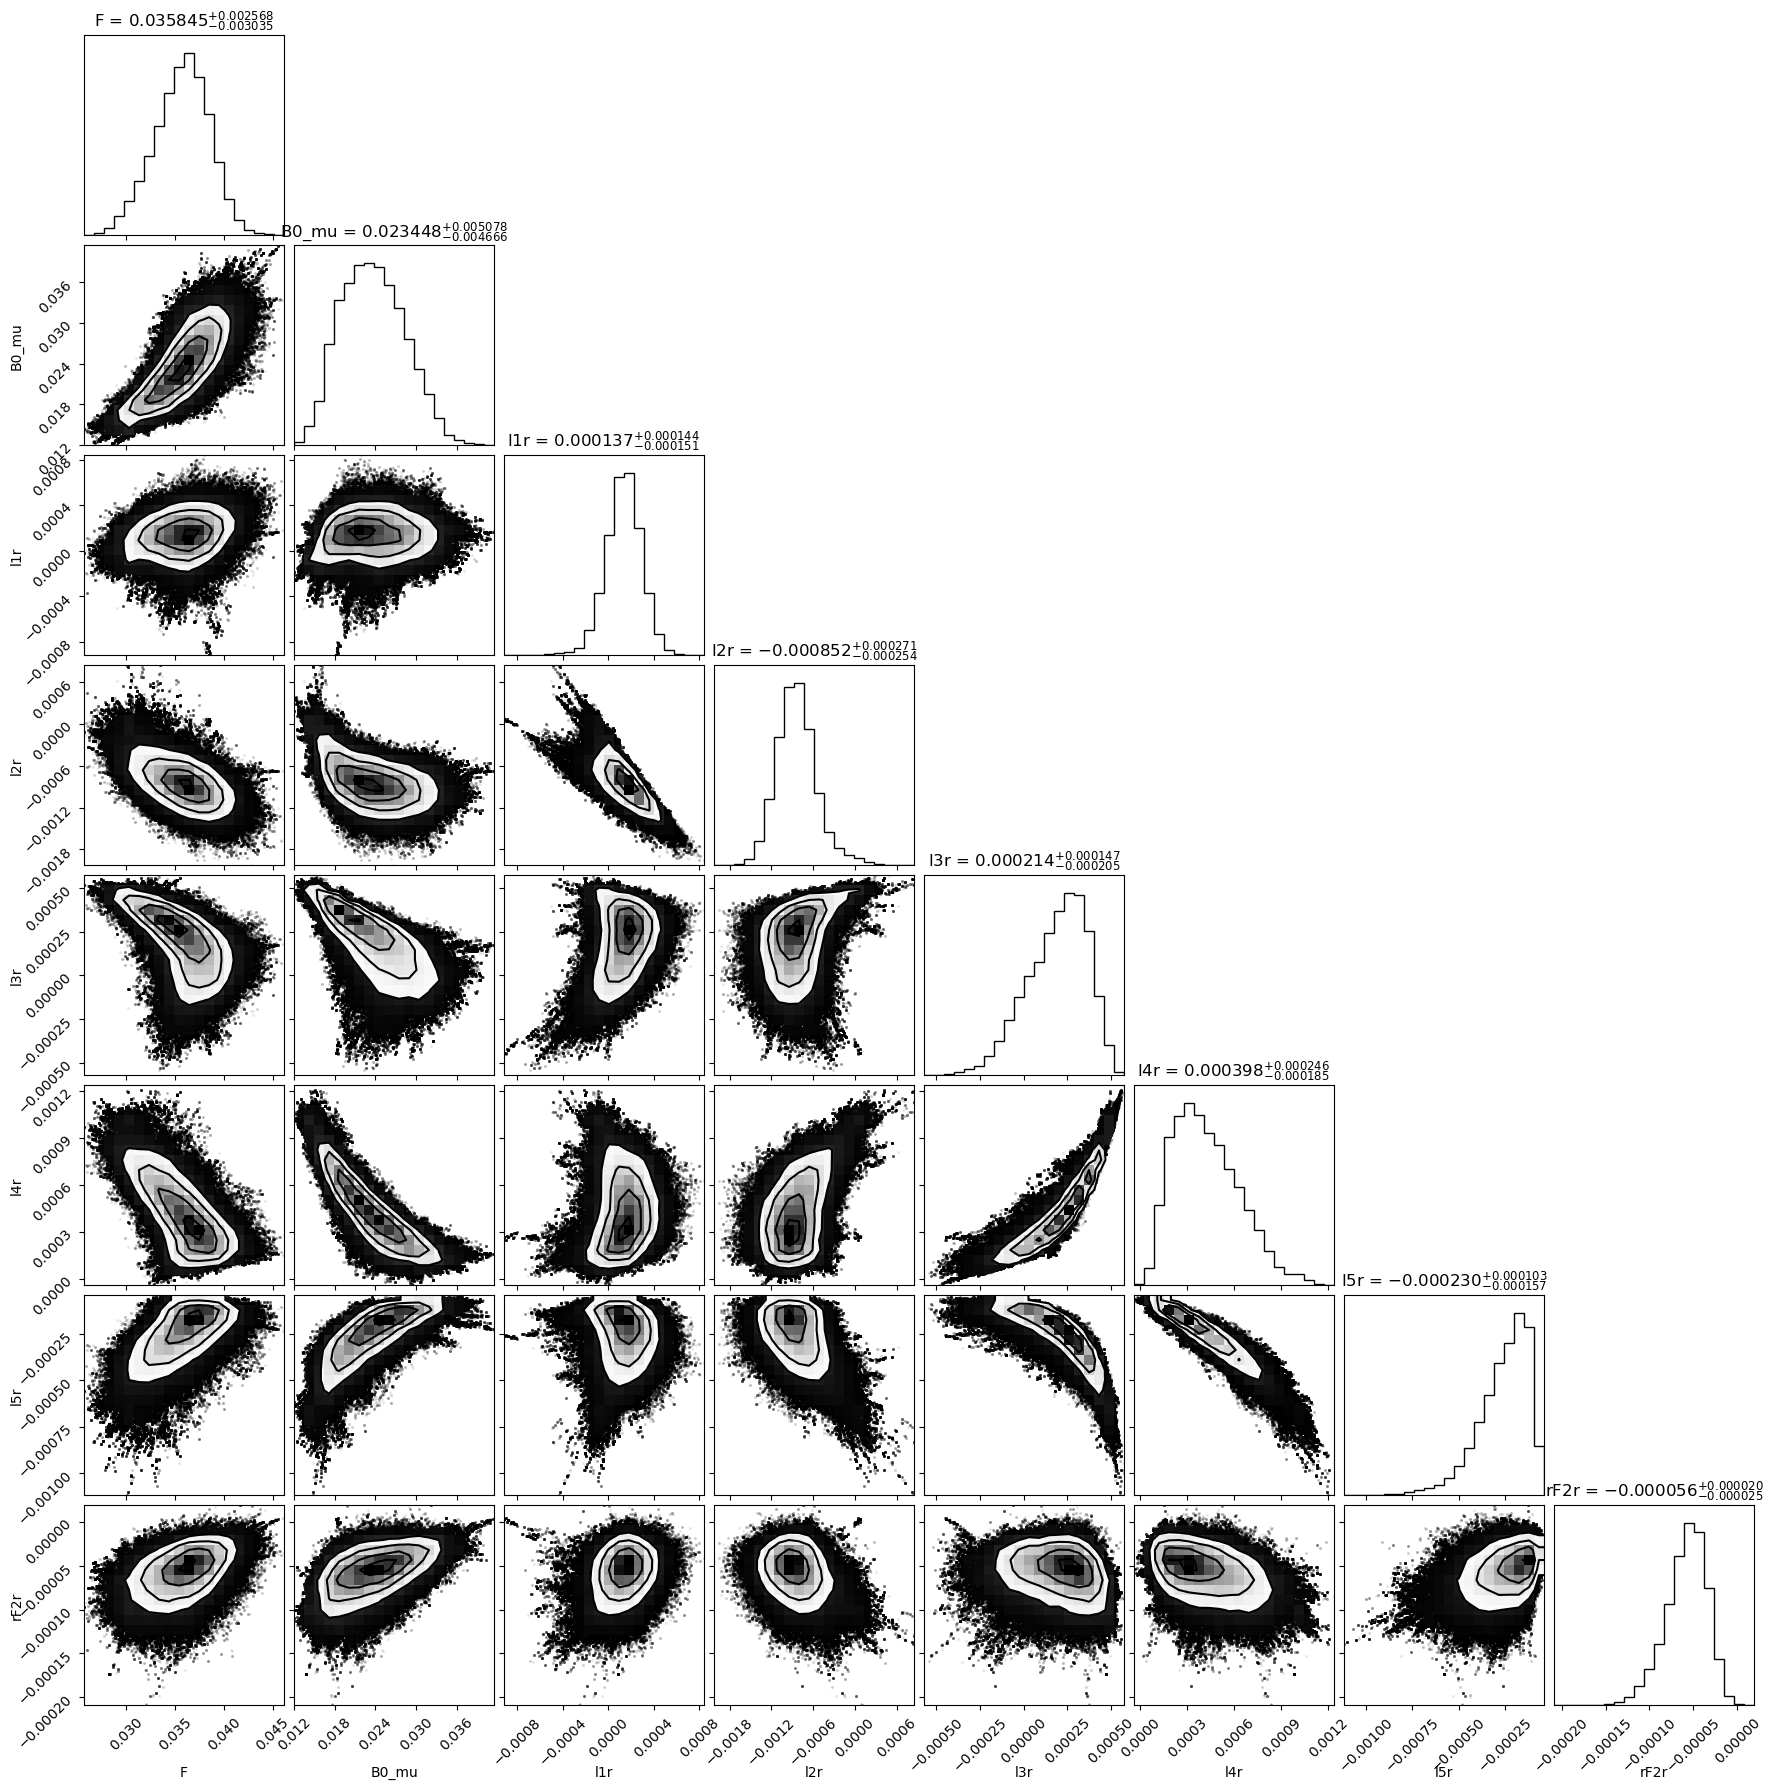

In [42]:
#choose first 8 parameters
selected_samples = samples[:, :8]

# Medians and и 1σ
medians = np.median(selected_samples, axis=0)
lower_errors = medians - np.percentile(selected_samples, 16, axis=0)
upper_errors = np.percentile(selected_samples, 84, axis=0) - medians

# Parameters' names
param_names = free_param_names

# Print results
for name, median, lower, upper in zip(param_names, medians, lower_errors, upper_errors):
    print(f"{name}: median = {median:.6f}, -1σ = {lower:.6f}, +1σ = {upper:.6f}")

mcmc_results = {
    name: {"median": median, "-1σ": lower, "+1σ": upper}
    for name, median, lower, upper in zip(param_names, medians, lower_errors, upper_errors)
}


# Generate the corner plot for the first 8 parameters
fig = corner.corner(
    selected_samples,
    labels=param_names,
    show_titles=True,
    title_fmt=".6f"
)

# Display the plot
plt.show()

# Plot for paper

<Figure size 1000x1000 with 0 Axes>

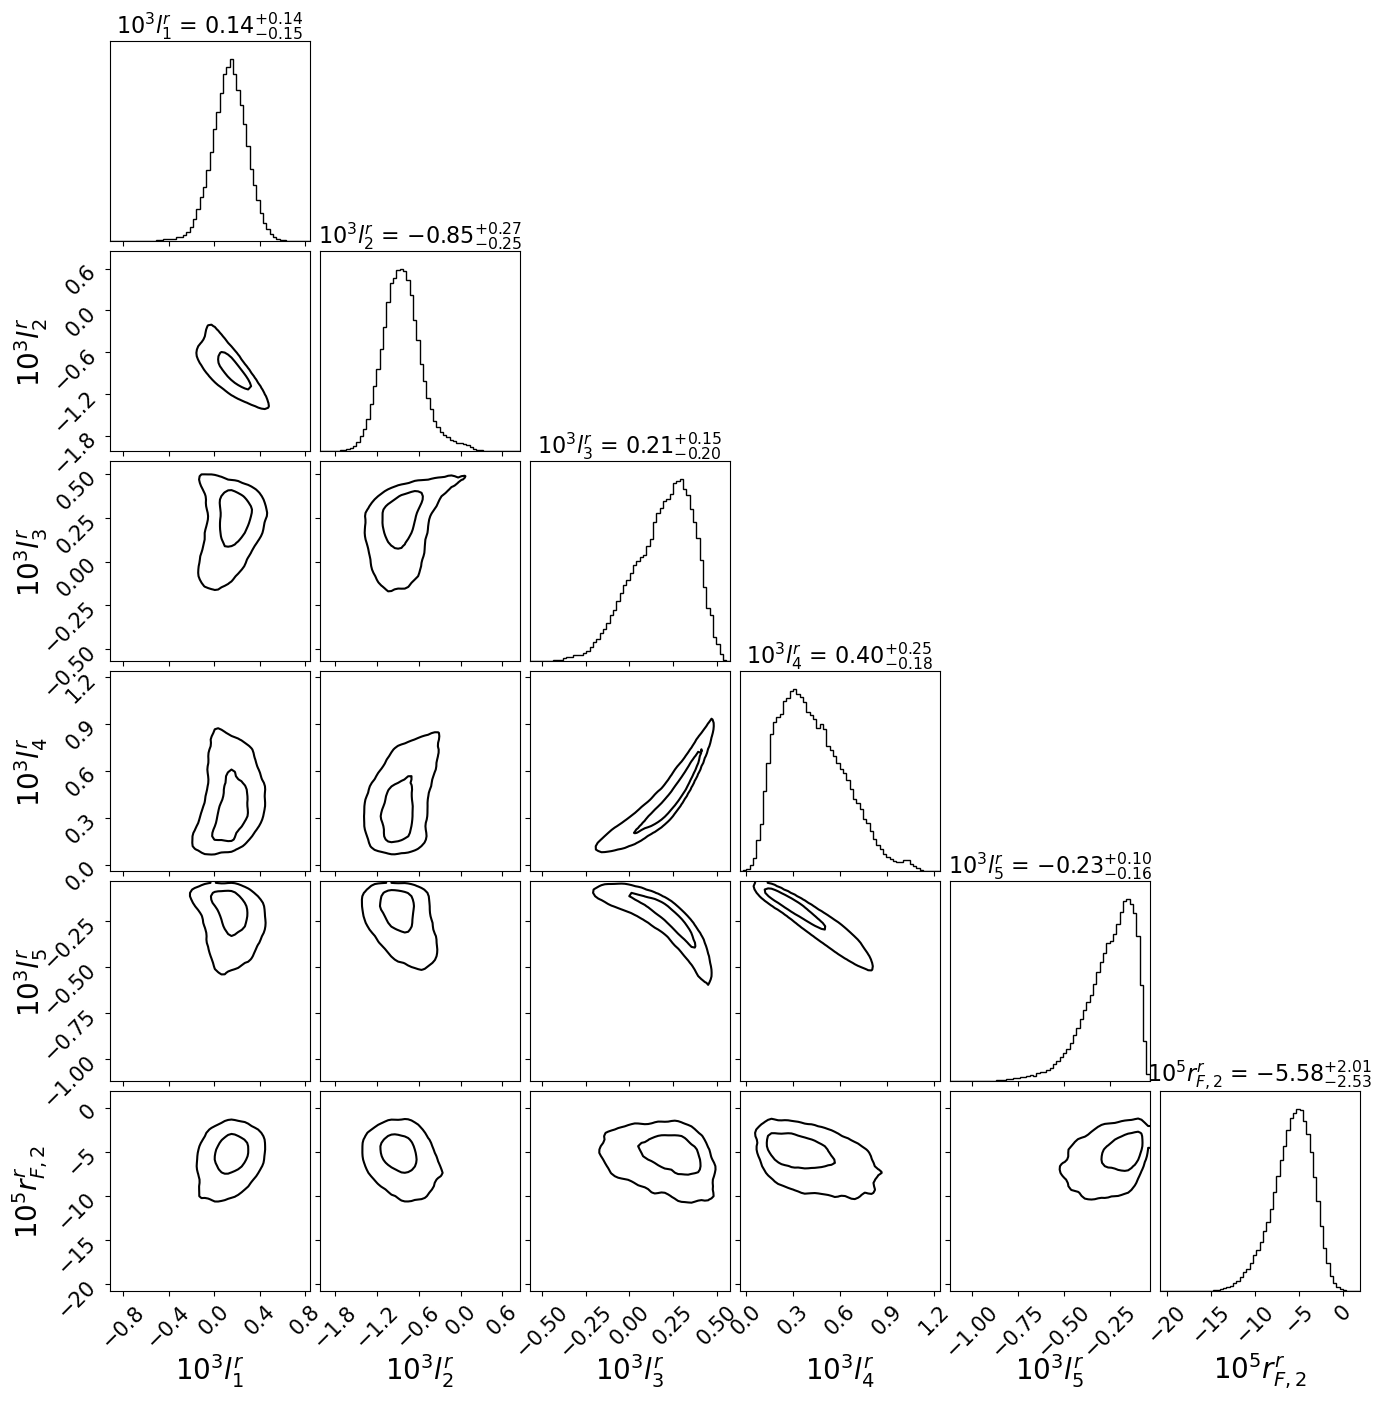

In [44]:
selected_samples_for_plot = selected_samples[:, -(n_free-2):]

# Rescale columns (example)
scales = np.array([1e3, 1e3, 1e3, 1e3, 1e3, 1e5])
selected_samples_for_plot = selected_samples_for_plot * scales

plt.figure(figsize=(10, 10))

fig = corner.corner(
    selected_samples_for_plot,
    labels=[
    r"$10^{3} l_1^{r}$",
    r"$10^{3} l_2^{r}$",
    r"$10^{3} l_3^{r}$",
    r"$10^{3} l_4^{r}$",
    r"$10^{3} l_5^{r}$",
    r"$10^{5} r_{F,2}^{r}$"],
    show_titles=True,
    title_fmt=".2f",

    # только контуры:
    plot_datapoints=False,   # без точек
    plot_density=False,      # выключить 2D-гистограмму (серую «плитку»)
    fill_contours=False,     # без заливки
    contour_kwargs={"colors": "black", "linewidths": 1.5},
    levels=[0.393, 0.865],  # 2σ
    #bins=33,
    bins=60,                               # больше бинов
    smooth=0.9,                            # гауссово сглаживание (в бинах)
    #smooth1d=5.0,
    # размеры шрифтов
    label_kwargs={"fontsize": 20},
    title_kwargs={"fontsize": 16}
)

# Увеличение размера чисел на осях
for ax in fig.axes:
    ax.tick_params(axis='both', labelsize=15)

# Сохранение
plt.savefig(
    "/Users/daniilkrichevskiy/Desktop/QCD-like-theories-at-NNLO/Plots/Posteriors.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()

In [46]:
mcmc_results

{'F': {'median': 0.03584507939248925,
  '-1σ': 0.003035268205858657,
  '+1σ': 0.002568466335281086},
 'B0_mu': {'median': 0.023447606549020398,
  '-1σ': 0.004666200977534212,
  '+1σ': 0.005077873703281062},
 'l1r': {'median': 0.0001368521188662435,
  '-1σ': 0.00015052124323539898,
  '+1σ': 0.00014385558258885747},
 'l2r': {'median': -0.0008523245842396352,
  '-1σ': 0.00025425064046608677,
  '+1σ': 0.000271260579759349},
 'l3r': {'median': 0.00021376365111985804,
  '-1σ': 0.00020492875210692925,
  '+1σ': 0.00014735400320367958},
 'l4r': {'median': 0.0003977097865903202,
  '-1σ': 0.00018498515716399176,
  '+1σ': 0.000246160944874275},
 'l5r': {'median': -0.00023006542596289023,
  '-1σ': 0.00015698590754734224,
  '+1σ': 0.00010304269035106995},
 'rF2r': {'median': -5.5790692767455766e-05,
  '-1σ': 2.5300226069227782e-05,
  '+1σ': 2.01466951143291e-05}}

## Plots for the fit

In [48]:
def func_LO(x):
    return (1 / np.pi) * (1 / 32) * x**2 #(2 / np.pi) * (1 / 32) * x**2
    
# Define the number of samples to take from the MCMC posterior
num_samples = 5000  # You can increase this for smoother uncertainty bands
indices = np.random.choice(len(samples), num_samples, replace=False)
posterior_samples = samples[indices, :]

# Generate prediction bands
r_mash = np.linspace(0.5, 8, 100)

x_func = np.linspace(0.1, 6, 100)
mass1 = Maas_x2_mass[0]
mass2 = Maas_x2_mass[1]
f_mash1 = mass1/x_func
f_mash2 = mass2/x_func

mA_samples = []
mC_samples = []
FA_samples = []
FC_samples = []
a0_mpi_samples1 = []
a0_mpi_samples2 = []


for params in posterior_samples:
    dictofParams = MCMC_vector_to_dictionary(params)
    
    
    mA_samples.append(mASquared(r_mash, dictofParams))
    mC_samples.append(mCSquared(r_mash, dictofParams))
    FA_samples.append(FA(r_mash, dictofParams))
    FC_samples.append(FC(r_mash, dictofParams))
    
    a0_mpi_samples1.append(a0_mPi(mass1, f_mash1, dictofParams))
    a0_mpi_samples2.append(a0_mPi(mass2, f_mash2, dictofParams))

# Convert to arrays
mA_samples = np.array(mA_samples)
mC_samples = np.array(mC_samples)
FA_samples = np.array(FA_samples)
FC_samples = np.array(FC_samples)
a0_mpi_samples1 = np.array(a0_mpi_samples1)
a0_mpi_samples2 = np.array(a0_mpi_samples2)

# Compute median and percentiles
mA_median = np.median(mA_samples, axis=0)
mA_lower = np.percentile(mA_samples, 16, axis=0)
mA_upper = np.percentile(mA_samples, 84, axis=0)

mC_median = np.median(mC_samples, axis=0)
mC_lower = np.percentile(mC_samples, 16, axis=0)
mC_upper = np.percentile(mC_samples, 84, axis=0)

FA_median = np.median(FA_samples, axis=0)
FA_lower = np.percentile(FA_samples, 16, axis=0)
FA_upper = np.percentile(FA_samples, 84, axis=0)

FC_median = np.median(FC_samples, axis=0)
FC_lower = np.percentile(FC_samples, 16, axis=0)
FC_upper = np.percentile(FC_samples, 84, axis=0)

a0_mpi_median1 = np.median(a0_mpi_samples1, axis=0)
a0_mpi_lower1 = np.percentile(a0_mpi_samples1, 16, axis=0)
a0_mpi_upper1 = np.percentile(a0_mpi_samples1, 84, axis=0)

a0_mpi_median2 = np.median(a0_mpi_samples2, axis=0)
a0_mpi_lower2 = np.percentile(a0_mpi_samples2, 16, axis=0)
a0_mpi_upper2 = np.percentile(a0_mpi_samples2, 84, axis=0)

y_func_LO = func_LO(x_func)

In [2]:
# ===========================
# 1. Masses Plot
# ===========================
plt.figure(figsize=(10, 6))
plt.errorbar(r[-n_r_point:], mPiASquared[-n_r_point:], yerr=DmPiASquared[-n_r_point:], xerr=Dr[-n_r_point:], 
             marker='o', label='Lattice data for $M^2_{\pi,1}$', linestyle='None', color="blue")
plt.plot(r_mash, mA_median, label="Fit of $M^2_{\pi,1}$", color="blue")
plt.fill_between(r_mash, mA_lower, mA_upper, color='blue', alpha=0.3, label='1σ')

plt.errorbar(r[-n_r_point:], mPiCSquared[-n_r_point:], yerr=DmPiCSquared[-n_r_point:], xerr=Dr[-n_r_point:], 
             marker='x', label='Lattice data for $M^2_{\pi,3}$', linestyle='None', color="red")
plt.plot(r_mash, mC_median, label="Fit of $M^2_{\pi,3}$", color="red")
plt.fill_between(r_mash, mC_lower, mC_upper, color='red', alpha=0.3, label='1σ')

plt.legend(fontsize=19)
#plt.title('Masses',fontsize=14)
plt.xlabel(r'$r = m_d^{\mathrm{PCAC}}/m_u^{\mathrm{PCAC}}$',fontsize=25)
plt.ylabel(r'pion masses squared, $a^{-2}$',fontsize=25)
plt.xlim(0, r[-n_r_point]+0.7)
plt.ylim(0.0, 0.5)
plt.grid(True)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.tight_layout()
plt.savefig("/Users/daniilkrichevskiy/Desktop/QCD-like-theories-at-NNLO/Plots/masses_plot.png", dpi=250)
plt.show()

# ===========================
# 2. Decay Constant Plot
# ===========================
plt.figure(figsize=(10, 6))
plt.errorbar(r[-n_r_point:], fA[-n_r_point:], yerr=DfA[-n_r_point:], xerr=Dr[-n_r_point:], 
             marker='x', label='Lattice  for $F_{\pi,1}$', linestyle='None', color="blue")
plt.plot(r_mash, FA_median, label="Fit of $F_{\pi,1}$", color="blue")
plt.fill_between(r_mash, FA_lower, FA_upper, color='blue', alpha=0.3, label='1σ')

plt.errorbar(r[-n_r_point:], fC[-n_r_point:], yerr=DfC[-n_r_point:], xerr=Dr[-n_r_point:], 
             marker='x', label='Lattice  for $F_{\pi,3}$', linestyle='None', color="blue")
plt.plot(r_mash, FC_median, label="Fit of $F_{\pi,3}$", color="blue")
plt.fill_between(r_mash, FC_lower, FC_upper, color='red', alpha=0.3, label='1σ')


plt.legend(fontsize = 20, loc='upper left')

#plt.title('Decay constant',fontsize=14)
plt.xlabel(r'$r = m_d^{\mathrm{PCAC}}/m_u^{\mathrm{PCAC}}$',fontsize=25)
plt.ylabel(r'decay constant, $a^{-1}$',fontsize=25)
plt.xlim(0, r[-n_r_point]+0.7)
plt.ylim(0.02, 0.12)
plt.grid(True)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.tight_layout()
plt.savefig("/Users/daniilkrichevskiy/Desktop/QCD-like-theories-at-NNLO/Plots/decay_constant_plot.png", dpi=250)
plt.show()

# ===========================
# 3. Scattering Length Plot
# ===========================

# we need to calculate here the x-points
x_points = Maas_x2_mass / Maas_x1_decay
x_pointsErr = x_points * np.sqrt((Maas_dx2_mass / Maas_x2_mass)**2 +(Maas_dx1_decay / Maas_x1_decay)**2)




plt.figure(figsize=(10, 6))
plt.errorbar(x_points, a0_mpi,
             yerr=(D_a0_mpi_lower[:1], D_a0_mpi_upper[:1]),
             xerr=x_pointsErr,
             marker='o', label='Lattice data', linestyle='None')
plt.plot(x_func, y_func_LO, label="LO", color='blue', linestyle='--')
plt.plot(x_func, a0_mpi_median1, label="NNLO, $M_\pi = 0.36a^{-1}$", color='black', linestyle='--')
plt.plot(x_func, a0_mpi_median2, label="NNLO, $M_\pi = 0.28a^{-1}$", color='grey', linestyle='--')
plt.fill_between(x_func, a0_mpi_lower1, a0_mpi_upper1, color='black', alpha=0.3, label='1σ')
plt.fill_between(x_func, a0_mpi_lower2, a0_mpi_upper2, color='grey', alpha=0.3, label='1σ')

plt.xlabel(r"$M_\pi/F_\pi$",fontsize=25)
plt.ylabel(r"$a_0^{MS}$",fontsize=25)
#plt.title('Scattering length',fontsize=14)
plt.xlim(0, 6)
plt.ylim(0.0, 1.0)
plt.gca().invert_yaxis()
yticks = np.linspace(0, 1, 5)
plt.yticks(yticks, [f"-{y:.1f}" for y in yticks])
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("/Users/daniilkrichevskiy/Desktop/QCD-like-theories-at-NNLO/Plots/scattering_length_plot.png", dpi=250)
plt.show()

NameError: name 'plt' is not defined

# Dark matter self scattering part

In [ ]:
def self_scattering_crossection_with_x(x, mpiPhys, muScale = 0.4, paramsListNew = [0, 0, 0, 0, 0, 0],  NNLO = True): #here x = m/f
    
    x2 = x**2
    mp2 = mpiPhys**2
    pi = np.pi
    
    if NNLO == True:

        l1r = paramsList["l1r"]
        l2r = paramsList["l2r"]
        l3r = paramsList["l3r"]
        l4r = paramsList["l4r"]
        l5r = paramsList["l5r"]
        rSIGMAr = paramsList["rSIGMAr"]
    
        Lp = pi16*np.log(mpiPhys**2 / muScale**2)
    
        pi16 = 1/(16.*np.pi**2)
    
        # Here mp2Phys obviously depends on the value of x (which is mp2Phys/fpi)
        Lp = pi16*np.log(mpiPhys**2 / muScale**2)
    
        Sigma2to2 = (mp2**(-1)*pi**(-1)*x2**2 * ( 9/512 )  + mp2**(-1)*pi**(-1)*x2**3 * ( 7/20*l4r + 19/20*l3r + 7/20*l2r + 7/20*l1r 
        - 451/5120*Lp + 383/5120*pi16 ) + mp2**(-1)*pi**(-1)*x2**4 * ( rSIGMAr - 56/5*l4r**2 - 304/5*l3r*l4r + 256/5*l3r**2 
        + 336/5*l2r*l4r - 112/5*l2r*l3r + 168/5*l2r**2 + 336/5*l1r*l4r
        - 112/5*l1r*l3r + 336/5*l1r*l2r + 168/5*l1r**2 - 1113/80*Lp*l4r 
        - 15/4*Lp*l3r - 803/80*Lp*l2r - 131/16*Lp*l1r + 64903/122880*Lp**2 + 567/80*pi16*l4r + 291/80*pi16*l3r 
        + 131/16*pi16*l2r + 671/80*pi16*l1r - 49517/61440*pi16*Lp + 46459/122880*pi16**2 )
        
        return Sigma2to2/mpiPhys
                     
    if NLO == False:
        Sigma2to2 = mp2**(-1)*pi**(-1)*x2**2 * ( 9/512 )  
        return Sigma2to2/mpiPhys

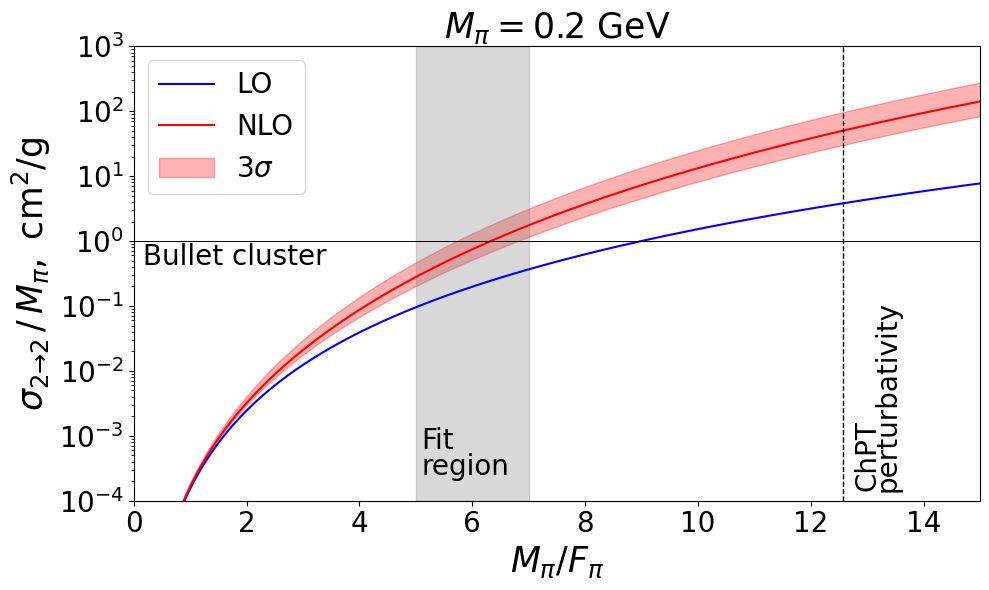

In [57]:
# Fix the mass to be 200 MeV = 0.2 GeV
m1 = 0.2

# Define the x = m_pi/f_pi -axis range
x_grid = np.linspace(0, 20, 500)
num_samples = 3000

# Sample from the MCMC posterior
indices = np.random.choice(len(samples), num_samples, replace=False)
posterior_samples = samples[indices, :]

# Compute predictions for each sample
y3_samples_x = []
for params in posterior_samples:
    L1, L2, L3, L4 = params[:4]  # Extract relevant parameters
    y3_samples_x.append([self_scattering_crossection_with_x(x, m1, LECs=[L1, L2, L3, L4], NLO=True) for x in x_grid])

# Convert to numpy array
y3_samples_x = np.array(y3_samples_x)

# Compute median and percentiles for 3σ bounds
y3_median_x = np.median(y3_samples_x, axis=0)
y3_lower_x = np.percentile(y3_samples_x, 0.15, axis=0)  # 3σ lower bound
y3_upper_x = np.percentile(y3_samples_x, 99.85, axis=0)  # 3σ upper bound



# Compute LO curve
y2_values_x = self_scattering_crossection_with_x(x_grid, m1, LECs=[0, 0, 0, 0], NLO=False)  # LO curve

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))


# LO curve
ax1.plot(x_grid, y2_values_x, 'blue', linestyle='-', label='LO')

# NLO curve with uncertainty bands
ax1.plot(x_grid, y3_median_x, 'red', label='NLO')
ax1.fill_between(x_grid, y3_lower_x, y3_upper_x, color='red', alpha=0.3, label=r'$3\sigma$ ')


#NNLO curve (we desided not to shw this)
#ax1.plot(x_grid, y4_median_x, 'orange', label='NNLO')
#ax1.fill_between(x_grid, y4_lower_x, y4_upper_x, color='orange', alpha=0.3, label=r'$1\sigma$ ')


# Axis formatting
ax1.set_xlabel(r"$M_\pi/F_\pi$",fontsize=25)
ax1.set_ylabel(r"$\sigma_{2 \to 2} \, / \, M_{\pi} , \ \mathrm{cm}**2 / \mathrm{g}$", color='black',fontsize=25)
ax1.set_yscale('log')
ax1.set_ylim(10**-4, 10**3)
ax1.set_xlim(min(x_grid), 15)
ax1.tick_params(axis='y', labelcolor='black', labelsize=20)
ax1.tick_params(axis='x', labelcolor='black', labelsize=20)

# Vertical line for ChPT perturbativity
ax1.axvline(x=4*np.pi, color='black', linestyle='--', linewidth=1)
ax1.text(4*np.pi + 0.2, 0.0005, r'ChPT', rotation=90, va='center', fontsize=20)
ax1.text(4*np.pi + 0.55, 0.004, r'perturbativity', rotation=90, va='center', fontsize=20)

# Horizontal line
ax1.axhline(y=10**0, color='black', linestyle='-', linewidth=0.7)
#ax1.fill_between(x_grid, 10**-1, 10**0, color='gray', alpha=0.3)
ax1.text(x=min(x_grid), y=0.35*10**0, s=" Bullet cluster", 
         verticalalignment='bottom', horizontalalignment='left', fontsize=20, color='black')

#vertical strip - the region where we have done the fit
ax1.axvspan(5, 7, color='gray', alpha=0.3)
ax1.text(x=5.1, y=5e-4, s="Fit", 
         verticalalignment='bottom', horizontalalignment='left', fontsize=20, color='black')
ax1.text(x=5.1, y=2e-4, s="region", 
         verticalalignment='bottom', horizontalalignment='left', fontsize=20, color='black')

# Legend
ax1.legend(loc='upper left', frameon=True, fontsize=20)

# Title and display
plt.title(r"$M_{\pi}=0.2 \ \mathrm{GeV}$", fontsize=25)
fig.tight_layout()
plt.savefig("/Users/daniilkrichevskiy/Desktop/New plots/Self_scattering.png", dpi=250)
plt.show()

In [58]:
#for the referee comment
target = 4 * np.pi
idx = np.argmin(np.abs(x_grid - target))
y3_median_x[idx]

50.521149443750055

In [61]:
LEC_samples = samples[:, :4]  # если нужно взять первые 4

num_samples = 200
indices = np.random.choice(len(LEC_samples), num_samples, replace=False)
posterior_samples = LEC_samples[indices, :]

assert posterior_samples.shape == (num_samples, 4), "Нужно ровно 4 значения на сэмпл"

# Пример функций/переменных
x_values = np.linspace(0, 30, 400)
m_values = np.logspace(-3, np.log10(3), 400)

Z = np.zeros((num_samples, len(x_values), len(m_values)))

for i in tqdm(range(num_samples)):
    L1, L2, L3, L4 = posterior_samples[i]
    for ix, x in enumerate(x_values):
        for im, m in enumerate(m_values):
            val = self_scattering_crossection_with_x(
                x, m, LECs=[L1, L2, L3, L4], NLO=True
            )
            Z[i, ix, im] = val

100%|█████████████████████████████████████████| 200/200 [00:30<00:00,  6.62it/s]


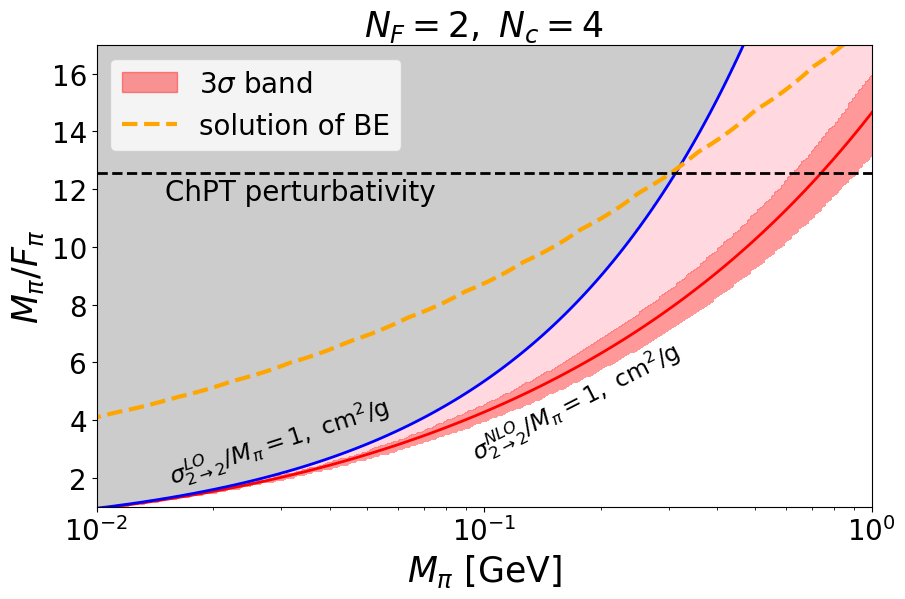

In [63]:
# m_values, x_values -- координатные массивы (1D),
# Z_lower, Z_upper   -- двумерные массивы, соответствующие (x_values, m_values).

#for LO
X, M = np.meshgrid(x_values, m_values)
Z_LO = self_scattering_crossection_with_x(X, M, LECs=[0, 0, 0, 0], NLO=False)

# Считаем медиану и, 3-сигма интервалы (0.15% и 99.85%):
Z_median = np.median(Z, axis=0)
Z_lower = np.percentile(Z, 0.15, axis=0)    # нижняя граница ~3σ
Z_upper = np.percentile(Z, 99.85, axis=0)   # верхняя граница ~3σ

plt.figure(facecolor='white', figsize=(10, 6))  # фон фигуры белый, без серого

# Заливка между линиями уровня LO и NLO — "область между 1 от Z_LO и Z_NLO"
mask_between = (Z_LO < 1) & (Z_lower.T > 1)
plt.contourf(M, X, mask_between, levels=[0.5, 1], colors=['pink'], alpha=1)

# Создаём булеву маску, где 1 находится "между" Z_lower и Z_upper
mask = (Z_lower < 1) & (Z_upper > 1)

# Закрашиваем область между Z_lower=1 и Z_upper=1 красным
# levels=[0, 0.5, 1] означает: False -> [0..0.5), True -> [0.5..1].
# Первый интервал красим 'white' (или 'none'), второй – 'red'.
plt.contourf(
    m_values,
    x_values,
    mask,
    levels=[0, 0.5, 1],
    colors=['white', 'red'],  # или ['none', 'red']
    alpha=0.4          # прозрачность по вкусу
)

#for NLO
#plt.contour(M, X, Z_median.T, levels=[1], linewidths=2, colors='black')
contour_nlo = plt.contour(M, X, Z_median.T, levels=[1], linewidths=2, colors='red')
#contour_nlo.collections[0].set_label(r'NLO self-scattering, $3*sigma$')  # Set label manually

#for LO
#plt.contour(M, X, Z_LO, levels=[1], linewidths=2,  color='blue', label = 'LO self-scattering')  # Линия разделения
# Заливка области выше линии LO (где Z_LO > 1)
plt.contourf(M, X, Z_LO, levels=[1,Z_LO.max()], colors=['gray'], alpha=0.4)
contour_lo = plt.contour(M, X, Z_LO, levels=[1], linewidths=2, colors='blue')
#contour_lo.collections[0].set_label('LO self-scattering')  # Set label manually

#m_pi/f_pi curve
y1_values = myNc4(m_values)
plt.plot(m_values, y1_values, color='orange', linestyle='--', linewidth=3, label = 'solution of BE')

# Добавляем горизонтальную линию 4π
plt.axhline(y=4 * np.pi, color="black", linestyle="--", linewidth=2)
plt.text(x=0.015, y=11.4, s="ChPT perturbativity", 
         verticalalignment='bottom', horizontalalignment='left', fontsize=20, color='black')

# #vertical lines
# xmin, xmax = 0.23, 0.47  # Adjust these values as needed
# plt.axvspan(xmin, xmax, color='g', alpha=0.3, label = "viability, LO")

# xmin, xmax = 0.58, 0.67  # Adjust these values as needed
# plt.axvspan(xmin, xmax, color='r', alpha=0.3, label = "viability, NLO" )

#self scattering bounds
plt.text(x=0.015, y=1.5, s=r"$\sigma**{LO}_{2\rightarrow 2} /M_{\pi } =1, \ \mathrm{cm}**2 / \mathrm{g}$", 
         verticalalignment='bottom', horizontalalignment='left', fontsize=17, color='black', rotation=18)
plt.text(x=0.09, y=2.35, s=r"$\sigma**{NLO}_{2\rightarrow 2} /M_{\pi } =1, \  \mathrm{cm}**2 / \mathrm{g}$", 
         verticalalignment='bottom', horizontalalignment='left', fontsize=17, color='black', rotation=27)

#, \ [\mathrm{cm}**2 / \mathrm{g}]

red_patch = mpatches.Patch(color='red', alpha=0.4, label=r'3$\sigma$ band')
plt.legend(handles=[red_patch, *plt.gca().get_legend_handles_labels()[0]], loc='upper left', fontsize=20)

# Настраиваем логарифмический масштаб по оси X
plt.xscale('log')
plt.xlim([0.01, 1])
#plt.ylim([6, 17])
plt.ylim([1, 17])
#plt.legend(fontsize=13)
plt.xlabel(r"$M_\pi$ [GeV]",fontsize=25)
plt.ylabel(r"$M_\pi/F_\pi$",fontsize=25)
plt.tick_params(axis='y', labelcolor='black', labelsize=20)
plt.tick_params(axis='x', labelcolor='black', labelsize=20)
plt.title(r"$N_F=2, \ N_с=4$", fontsize=25)
plt.savefig("/Users/daniilkrichevskiy/Desktop/New plots/SIMP_regions.png", dpi=250, bbox_inches='tight')
plt.show()

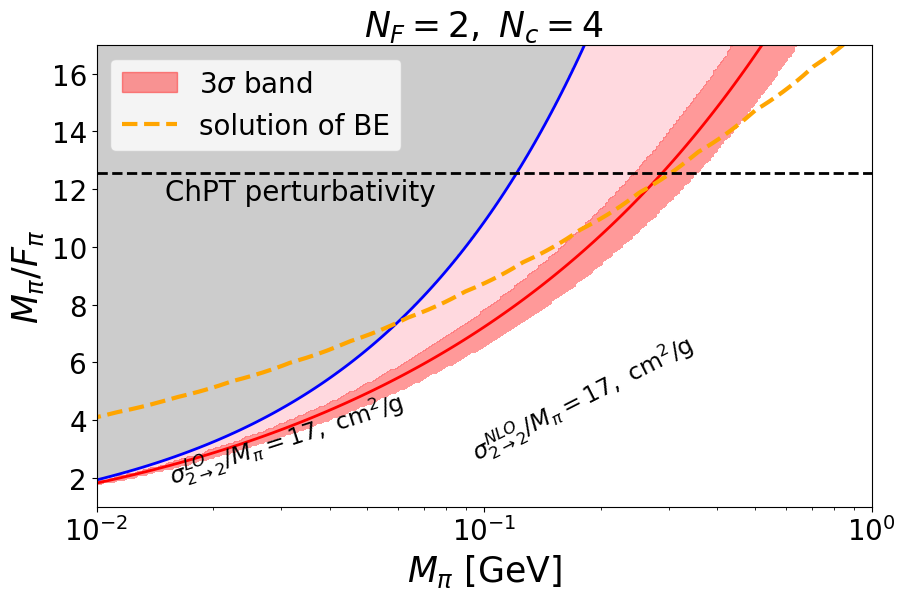

In [97]:
#to find the level of sigma/m bound where we would see that NLO allows

sigma_level = 17   # <<< ГРАНИЦА СЕЙЧАС ЗДЕСЬ

# m_values, x_values -- координатные массивы (1D),
# Z_lower, Z_upper   -- двумерные массивы, соответствующие (x_values, m_values).

# ===== LO =====
X, M = np.meshgrid(x_values, m_values)
Z_LO = self_scattering_crossection_with_x(X, M, LECs=[0, 0, 0, 0], NLO=False)

# ===== NLO statistics =====
Z_median = np.median(Z, axis=0)
Z_lower  = np.percentile(Z, 0.15,  axis=0)
Z_upper  = np.percentile(Z, 99.85, axis=0)

plt.figure(facecolor='white', figsize=(10, 6))

# ===== LO–NLO crossing region =====
mask_between = (Z_LO < sigma_level) & (Z_lower.T > sigma_level)

plt.contourf(M, X, mask_between,
             levels=[0.5, 1],
             colors=['pink'],
             alpha=1)

# ===== 3σ band =====
mask = (Z_lower < sigma_level) & (Z_upper > sigma_level)

plt.contourf(m_values,
             x_values,
             mask,
             levels=[0, 0.5, 1],
             colors=['white', 'red'],
             alpha=0.4)

# ===== NLO contour =====
contour_nlo = plt.contour(M, X, Z_median.T,
                          levels=[sigma_level],
                          linewidths=2,
                          colors='red')

# ===== LO region (Z_LO > sigma_level) =====
plt.contourf(M, X, Z_LO,
             levels=[sigma_level, Z_LO.max()],
             colors=['gray'],
             alpha=0.4)

contour_lo = plt.contour(M, X, Z_LO,
                         levels=[sigma_level],
                         linewidths=2,
                         colors='blue')

# ===== m_pi/f_pi curve =====
y1_values = myNc4(m_values)
plt.plot(m_values, y1_values,
         color='orange',
         linestyle='--',
         linewidth=3,
         label='solution of BE')

# ===== 4π line =====
plt.axhline(y=4*np.pi,
            color="black",
            linestyle="--",
            linewidth=2)

plt.text(x=0.015,
         y=11.4,
         s="ChPT perturbativity",
         verticalalignment='bottom',
         horizontalalignment='left',
         fontsize=20,
         color='black')

# ===== self–scattering labels =====
plt.text(x=0.015,
         y=1.5,
         s=rf"$\sigma**{{LO}}_{{2\rightarrow 2}} /M_{{\pi }} ={sigma_level},\ \mathrm{{cm}}**2 / \mathrm{{g}}$",
         verticalalignment='bottom',
         horizontalalignment='left',
         fontsize=17,
         color='black',
         rotation=18)

plt.text(x=0.09,
         y=2.35,
         s=rf"$\sigma**{{NLO}}_{{2\rightarrow 2}} /M_{{\pi }} ={sigma_level},\ \mathrm{{cm}}**2 / \mathrm{{g}}$",
         verticalalignment='bottom',
         horizontalalignment='left',
         fontsize=17,
         color='black',
         rotation=27)

# ===== legend =====
red_patch = mpatches.Patch(color='red',
                           alpha=0.4,
                           label=r'3$\sigma$ band')

plt.legend(handles=[red_patch,
                    *plt.gca().get_legend_handles_labels()[0]],
           loc='upper left',
           fontsize=20)

# ===== axes =====
plt.xscale('log')
plt.xlim([0.01, 1])
plt.ylim([1, 17])

plt.xlabel(r"$M_\pi$ [GeV]", fontsize=25)
plt.ylabel(r"$M_\pi/F_\pi$", fontsize=25)

plt.tick_params(axis='y', labelcolor='black', labelsize=20)
plt.tick_params(axis='x', labelcolor='black', labelsize=20)

plt.title(r"$N_F=2, \ N_c=4$", fontsize=25)

plt.savefig("/Users/daniilkrichevskiy/Desktop/New plots/SIMP_regions.png",
            dpi=250,
            bbox_inches='tight')

plt.show()

## Here we define up to which x we can trust the LO 

## With our LECs:

In [65]:
mcmc_results['L4']['median']

-1.871760904732661

In [73]:
def find_trust_region(threshold=1.0, x_max=14, step=0.01):
    trusted_x = None
    x = 0.0
    while x <= x_max:
        lo = self_scattering_crossection_with_x(x, 0.3, LECs=[mcmc_results['L1']['median'], mcmc_results['L2']['median'], mcmc_results['L3']['median'], mcmc_results['L4']['median']], NLO=False)
        nlo = self_scattering_crossection_with_x(x, 0.3, LECs=[mcmc_results['L1']['median'], mcmc_results['L2']['median'], mcmc_results['L3']['median'], mcmc_results['L4']['median']], NLO=True)
        
        if lo == 0:
            x += step
            continue
        
        relative_diff = abs(nlo - lo) / abs(lo)
        if relative_diff > threshold:
            break
        
        trusted_x = x
        x += step

    return trusted_x

find_trust_region()

3.649999999999966

## With zero LECs we get same as Sannino

In [69]:
def find_trust_region(threshold=0.2, x_max=14, step=0.01):
    trusted_x = None
    x = 0.0
    while x <= x_max:
        lo = self_scattering_crossection_with_x(x, 0.3, LECs=[0, 0, 0, 0], NLO=False)
        nlo = self_scattering_crossection_with_x(x, 0.3, LECs=[0, 0, 0, 0], NLO=True)
        
        if lo == 0:
            x += step
            continue
        
        relative_diff = abs(nlo - lo) / abs(lo)
        if relative_diff > threshold:
            break
        
        trusted_x = x
        x += step

    return trusted_x

find_trust_region()

2.719999999999986